In [76]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

In [77]:
np.random.seed(13)
num_samples = 1000
time_steps = 10  # Длина временного окна

In [78]:
# Параметры: скидка, сезонность, регион (закодированные), история возвратов
discount = np.random.uniform(0, 1, num_samples)
seasonality = np.random.choice([0, 1], num_samples)  # 0 - вне сезона, 1 - сезон
region = np.random.choice([0, 1, 2], num_samples)  # Три региона
return_history = np.random.choice([0, 1], num_samples, p=[0.8, 0.2])  # Вероятность возврата

In [79]:
# Объединение данных в DataFrame
data = pd.DataFrame({
    'Discount': discount,
    'Seasonality': seasonality,
    'Region': region,
    'Return_History': return_history
})

In [80]:
# Нормализация данных
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [81]:
# Подготовка входных и целевых данных
X = []
y = []

for i in range(time_steps, len(scaled_data)):
    X.append(scaled_data[i-time_steps:i, :])  # Входные данные
    y.append(scaled_data[i, 3])  # Целевой столбец (Return_History)

X, y = np.array(X), np.array(y)

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

In [83]:
# Создание модели RNN с LSTM
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1, activation='sigmoid'))  # Выходной слой для вероятности возврата

C:\Users\santa\PycharmProjects\Diploma\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [84]:
from tensorflow.keras.callbacks import EarlyStopping

# Добавляем раннюю остановку
early_stopping = EarlyStopping(
    monitor='val_loss',  # Метрика для отслеживания (потеря на валидации)
    patience=10,         # Количество эпох без улучшения перед остановкой
    restore_best_weights=True  # Восстанавливает веса с наименьшей потерей на валидации
)

# Компиляция модели
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Обучение модели с ранней остановкой
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]  # Передаем раннюю остановку в колбэках
)

# Оценка модели
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Тестовая точность: {accuracy:.4f}")

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6458 - loss: 0.6686 - val_accuracy: 0.7424 - val_loss: 0.5880
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7963 - loss: 0.5234 - val_accuracy: 0.7424 - val_loss: 0.5884
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8044 - loss: 0.4959 - val_accuracy: 0.7424 - val_loss: 0.5829
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7917 - loss: 0.5104 - val_accuracy: 0.7424 - val_loss: 0.5897
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8067 - loss: 0.4939 - val_accuracy: 0.7424 - val_loss: 0.5897
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8066 - loss: 0.4897 - val_accuracy: 0.7424 - val_loss: 0.5831
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8137 - loss: 0.4831 - val_accuracy: 0.7424 - val_loss: 0.5891
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7904 - loss: 0.5173 - val_accuracy: 0.7424 - 

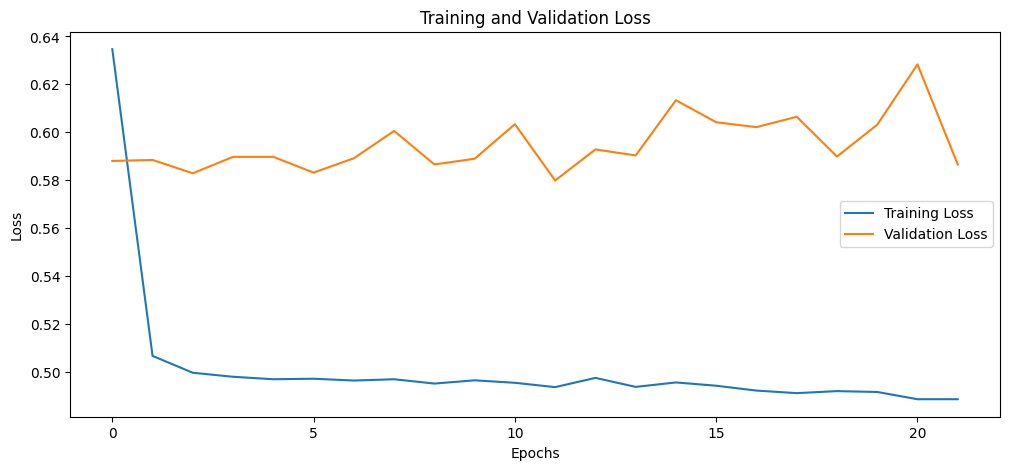

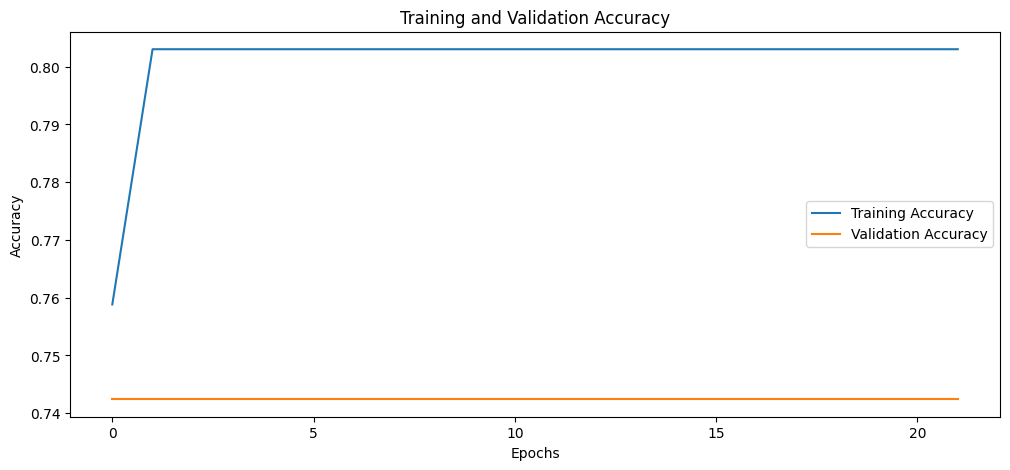

In [85]:
import matplotlib.pyplot as plt

# График потерь (Loss)
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()
'''
График функции потерь (Loss) для обучающей и валидационной выборок — показывает, как уменьшалась ошибка модели по мере обучения.
График точности (Accuracy) для обучающей и валидационной выборок — позволяет понять, насколько хорошо модель предсказывает вероятность возврата.
'''
# График точности (Accuracy)
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()
